In [21]:
# Quantum-Safe Banking Communications

## Classical Cryptography Prototype

### Objective: To simulate secure communication between a customer and a bank using 
#classical cryptographic techniques. The prototype demonstrates secure session key exchange using
#RSA and confidential message transmission using AES-256.

### Workflow
#1. Generate RSA public/private key pair.
#2. Generate a random AES-256 session key.
#4. Decrypt the AES session key using the RSA private key.
#5. Encrypt a banking transaction using AES-256.
# A complete proof-of-concept demonstrating secure key exchange and encrypted communication 
#using classical cryptography.

In [22]:
## 1. Import Required Libraries
# RSA

from cryptography.hazmat.primitives.asymmetric import rsa
from cryptography.hazmat.primitives.asymmetric import padding

# Hashing
from cryptography.hazmat.primitives import hashes

# AES
from cryptography.hazmat.primitives.ciphers import Cipher, algorithms, modes

# Padding for AES
from cryptography.hazmat.primitives import padding as sym_padding

# Random bytes
import os

# Timing
import time

In [23]:
## 2. Generate RSA Key Pair
# Generate RSA private key

private_key = rsa.generate_private_key(
    public_exponent=65537,
    key_size=2048
)

# Extract public key

public_key = private_key.public_key()

print("RSA key pair generated successfully!")

RSA key pair generated successfully!


In [24]:
print(private_key)
print(public_key)

In [25]:
## 3. Generate AES-256 Session Key
aes_key = os.urandom(32)

print("AES-256 Key Generated!")

print(aes_key)

AES-256 Key Generated!
b'vl\x06\xb8\xb1Bf\x84\xd1\xef\x90\xb5\x05P;\xa6N\x8d\xd7\x9e\x1c\x85\xc9\xf2Dgn\x96\xfb\xba\x98\xd8'


In [26]:
# Section 4: Secure Session Key Exchange Using RSA
encrypted_aes_key = public_key.encrypt(
    aes_key,
    padding.OAEP(
        mgf=padding.MGF1(algorithm=hashes.SHA256()),
        algorithm=hashes.SHA256(),
        label=None
    )
)

print("AES key encrypted successfully!")

AES key encrypted successfully!


In [27]:
print(encrypted_aes_key)

b"eE\xe9\xc9(]\x9d\x8d\xcc\x91\xe4\xc5f\xb5\xe5\xc9\xe7O[\xc8\x03\xa5\x07\x1c_\xa0x.J\xf0Sa\xe4\xf3\xebJ\xb9*\xed3\xa0\x8c\xd1k\x0e\x03\xe7{\xbbp\x06d\xe2[\x10s\x101\x82\xe9\xa7\xdc9\x85\xdf\xdeI\xa5\x07y\xdc\xef\x1e\x8c.\xa3|f\x8brU\xc9\x17\x95\xc0\x10C\xd2]\x08\x87\xcfu3\xfdM%\x1e|\x1c\xbf\xf9\x99\xc3\xe6~!\x8c\x04CN\xd5\xbcCM-}\xb8\xbd\xbf\x1a'\x80\xd1\x0fo\x97\x92J\x8f\xf3e\xb0\xa8\x0cM\x17\xc0|\x1b\xe8\xa4\xda>}\xad\xc8\x94\x86f\xec\x88A\xfe\x887\x85G\xd4\xf4cT}\xdb\xf9\x07\x14\x0b\x81\xfb\xf1@\x14WA7h\x95\xea\xb4\xa9\xf9r\x1e\x10W2 2\xb4}\x101\x7f\x98@ba\xba\x8a\xa8p\xc9\xe2\x04,\xb1 V\xd4\xa0\xde\xce\x1e3\xb2\xd5S\xf9Guus\x88\x9c\x83\xc0=\xd9FM\x85;!N\x15\xbf\xfa\xd3\x9e\x7f\x05\x0f\x7f\x83\x05m2\x01H\xfc^Ai\x8e\x1b"


In [28]:
print("Original AES key length:", len(aes_key), "bytes")
print("Encrypted AES key length:", len(encrypted_aes_key), "bytes")

Original AES key length: 32 bytes
Encrypted AES key length: 256 bytes


In [29]:
decrypted_aes_key = private_key.decrypt(
    encrypted_aes_key,
    padding.OAEP(
        mgf=padding.MGF1(algorithm=hashes.SHA256()),
        algorithm=hashes.SHA256(),
        label=None
    )
)

print("AES key decrypted successfully!")

AES key decrypted successfully!


In [30]:
print("Original AES Key:")
print(aes_key)

print("\nDecrypted AES Key:")
print(decrypted_aes_key)

Original AES Key:
b'vl\x06\xb8\xb1Bf\x84\xd1\xef\x90\xb5\x05P;\xa6N\x8d\xd7\x9e\x1c\x85\xc9\xf2Dgn\x96\xfb\xba\x98\xd8'

Decrypted AES Key:
b'vl\x06\xb8\xb1Bf\x84\xd1\xef\x90\xb5\x05P;\xa6N\x8d\xd7\x9e\x1c\x85\xc9\xf2Dgn\x96\xfb\xba\x98\xd8'


In [31]:
if aes_key == decrypted_aes_key:
    print("SUCCESS! The AES keys match.")
else:
    print("ERROR! The AES keys do not match.")

SUCCESS! The AES keys match.


In [32]:
# Section 5: Banking Transaction Simulation
def generate_rsa_keypair():
    ...

In [33]:
{
  "sender": "Tripti",
  "receiver": "ABC Store",
  "amount": 5000,
  "currency": "INR"
}

{'sender': 'Tripti',
 'receiver': 'ABC Store',
 'amount': 5000,
 'currency': 'INR'}

In [34]:
transaction = """
Transaction ID : TXN1001
From           : Tripti Gupta
To             : ABC Electronics
Amount         : ₹5000
Currency       : INR
Status         : Pending
"""

print(transaction)


Transaction ID : TXN1001
From           : Tripti Gupta
To             : ABC Electronics
Amount         : ₹5000
Currency       : INR
Status         : Pending



In [35]:
transaction_bytes = transaction.encode()

print(transaction_bytes)

b'\nTransaction ID : TXN1001\nFrom           : Tripti Gupta\nTo             : ABC Electronics\nAmount         : \xe2\x82\xb95000\nCurrency       : INR\nStatus         : Pending\n'


In [36]:
iv = os.urandom(16)

print(iv)

b'\x06\x17\x1b\x80\n\x98\xc7`0+\xc8\xa4\xe1`m\x04'


In [37]:
padder = sym_padding.PKCS7(128).padder()

padded_data = padder.update(transaction_bytes)

padded_data += padder.finalize()

print("Padding complete!")

Padding complete!


In [38]:
# Section 6: AES Encryption of Transaction
cipher = Cipher(
    algorithms.AES(decrypted_aes_key),
    modes.CBC(iv)
)

encryptor = cipher.encryptor()

ciphertext = encryptor.update(padded_data)

ciphertext += encryptor.finalize()

print("Transaction encrypted successfully!")

Transaction encrypted successfully!


In [39]:
print(ciphertext)

b'\x93H\xb4r;\x93M\x81\x96\xc9z\xce\xb8\x00t\xe0\x19\x83#\x077\xd8\xb5\x0c\x98\x00k\x11a<\xc3cw\x1fyC\x965\xe7\xb7\xb6t[l{\xbc\xd9\xc7Jk>\xb2\xce"~\x17\x8f\xca\xc5\xaba\x1b\x01\xd9p\xe8#\xcdm\xaa\xbeO[\xe99\xd3\t\xcf\x1c\xe4\xa9\x86\xaa\x0b\xe0\t\x0c\x03~\xf5\xd7\xf8\x1b\xc27\xd0\x82\xf0\x0b&kr\x8csU\xd7\xefW\x08@\xb8{\xb5\xb1\'\xdc\xa4v\xc0\x11Vra\xea\xbb\x04]0\x96\xc9w\xce$\xbe\xd6bK\x0cW]1:\x07\xe8\x1b\x19\xbc\xb6/\xb9\x89\xa2\xb7\xa6\x7f\xfc8J\xb4yQ\xdb\x04R:\xf1#j9w\xd3\xf0\xa1\xc4\x95\x83'


In [41]:
# Section 7: AES Decryption of Transaction
cipher = Cipher(
    algorithms.AES(decrypted_aes_key),
    modes.CBC(iv)
)

decryptor = cipher.decryptor()

decrypted_padded = decryptor.update(ciphertext)
decrypted_padded += decryptor.finalize()

print("Transaction decrypted successfully!")

Transaction decrypted successfully!


In [42]:
unpadder = sym_padding.PKCS7(128).unpadder()

decrypted_message = unpadder.update(decrypted_padded)
decrypted_message += unpadder.finalize()

print("Padding removed successfully!")

Padding removed successfully!


In [44]:
# Section 8: Verification
final_message = decrypted_message.decode()

print(final_message)


Transaction ID : TXN1001
From           : Tripti Gupta
To             : ABC Electronics
Amount         : ₹5000
Currency       : INR
Status         : Pending



In [23]:
print("Original Transaction:")
print(transaction)

print("\nRecovered Transaction:")
print(final_message)

print("\nMatch:", transaction == final_message)

Original Transaction:

Transaction ID : TXN1001
From           : Tripti Gupta
To             : ABC Electronics
Amount         : ₹5000
Currency       : INR
Status         : Pending


Recovered Transaction:

Transaction ID : TXN1001
From           : Tripti Gupta
To             : ABC Electronics
Amount         : ₹5000
Currency       : INR
Status         : Pending


Match: True


In [45]:
# Section 9: Benchmarking Classical Cryptography

In [46]:
import time
import statistics

In [47]:
rsa_keygen_times = []
rsa_encrypt_times = []
rsa_decrypt_times = []

In [48]:
NUM_RUNS = 30

In [50]:
rsa_keygen_times = []

NUM_RUNS = 30

for i in range(NUM_RUNS):

    start = time.perf_counter()

    private_key = rsa.generate_private_key(
        public_exponent=65537,
        key_size=2048
    )

    public_key = private_key.public_key()

    end = time.perf_counter()

    rsa_keygen_times.append((end-start)*1000)

In [51]:
print(rsa_keygen_times)

[100.8582089561969, 206.12483308650553, 153.0297080753371, 222.2370409872383, 79.91754205431789, 119.677959010005, 40.46550008933991, 88.104791007936, 138.98100005462766, 226.99016600381583, 171.9924589851871, 186.3275000359863, 131.75229192711413, 75.42429200839251, 184.6326250815764, 317.4725000280887, 137.77675002347678, 282.8015830600634, 309.40783303231, 160.3559999493882, 249.29175002034754, 101.02433408610523, 49.12908293772489, 180.88391702622175, 126.6228329623118, 223.9017499377951, 315.82195789087564, 129.99229098204523, 49.746125005185604, 137.36983307171613]


In [52]:
print(f"Average : {statistics.mean(rsa_keygen_times):.3f} ms")

print(f"Minimum : {min(rsa_keygen_times):.3f} ms")

print(f"Maximum : {max(rsa_keygen_times):.3f} ms")

print(f"Std Dev : {statistics.stdev(rsa_keygen_times):.3f} ms")

Average : 163.270 ms
Minimum : 40.466 ms
Maximum : 317.473 ms
Std Dev : 78.995 ms


In [53]:
# Section 10: Benchmark RSA Encryption

In [54]:
rsa_encrypt_times = []

NUM_RUNS = 30

for i in range(NUM_RUNS):

    # Generate a fresh RSA key pair for this iteration
    private_key = rsa.generate_private_key(
        public_exponent=65537,
        key_size=2048
    )

    public_key = private_key.public_key()

    # Fresh AES session key
    aes_key = os.urandom(32)

    start = time.perf_counter()

    encrypted_aes_key = public_key.encrypt(
        aes_key,
        padding.OAEP(
            mgf=padding.MGF1(algorithm=hashes.SHA256()),
            algorithm=hashes.SHA256(),
            label=None
        )
    )

    end = time.perf_counter()

    rsa_encrypt_times.append((end-start)*1000)

In [55]:
print(f"Average : {statistics.mean(rsa_encrypt_times):.3f} ms")
print(f"Minimum : {min(rsa_encrypt_times):.3f} ms")
print(f"Maximum : {max(rsa_encrypt_times):.3f} ms")
print(f"Std Dev : {statistics.stdev(rsa_encrypt_times):.3f} ms")

Average : 0.176 ms
Minimum : 0.121 ms
Maximum : 0.294 ms
Std Dev : 0.042 ms


In [56]:
# Section 11: Benchmark RSA Decryption

In [57]:
rsa_decrypt_times = []

NUM_RUNS = 30

for i in range(NUM_RUNS):

    private_key = rsa.generate_private_key(
        public_exponent=65537,
        key_size=2048
    )

    public_key = private_key.public_key()

    aes_key = os.urandom(32)

    encrypted_aes_key = public_key.encrypt(
        aes_key,
        padding.OAEP(
            mgf=padding.MGF1(algorithm=hashes.SHA256()),
            algorithm=hashes.SHA256(),
            label=None
        )
    )

    start = time.perf_counter()

    decrypted_key = private_key.decrypt(
        encrypted_aes_key,
        padding.OAEP(
            mgf=padding.MGF1(algorithm=hashes.SHA256()),
            algorithm=hashes.SHA256(),
            label=None
        )
    )

    end = time.perf_counter()

    rsa_decrypt_times.append((end-start)*1000)

In [60]:
# Experiment Environment

#**Machine**
#- Apple MacBook Pro (M2)

#**Operating System**
#- macOS

#**Programming Language**
#- Python 3.x

#**Cryptography Library**
#- cryptography

#**Benchmark Method**
#- `time.perf_counter()`

#**Number of Benchmark Runs**
#- 30

#**Purpose**
#- To establish a classical cryptography baseline before implementing
#post-quantum cryptography (ML-KEM).

In [61]:
# Section 12: Benchmark Results Summary

In [62]:
import pandas as pd

In [63]:
rsa_keygen_times

rsa_encrypt_times

rsa_decrypt_times

[3.982999944128096,
 3.8549579912796617,
 3.9762919768691063,
 3.915000008419156,
 3.9117500418797135,
 4.021208034828305,
 4.026165930554271,
 3.908707993105054,
 3.9804169209674,
 4.028042079880834,
 3.966833930462599,
 4.0238749934360385,
 3.9913340006023645,
 3.924375050701201,
 4.028375027701259,
 4.10270900465548,
 3.986916970461607,
 4.045500070787966,
 3.9960830472409725,
 3.978458931669593,
 4.068124922923744,
 4.050125018693507,
 4.02458303142339,
 3.9126670453697443,
 3.856915980577469,
 4.036374972201884,
 3.997207968495786,
 3.905458957888186,
 3.915332956239581,
 3.9176669670268893]

In [64]:
benchmark_results = pd.DataFrame({
    "Operation": [
        "RSA Key Generation",
        "RSA Encryption",
        "RSA Decryption"
    ],

    "Average Time (ms)": [
        statistics.mean(rsa_keygen_times),
        statistics.mean(rsa_encrypt_times),
        statistics.mean(rsa_decrypt_times)
    ],

    "Minimum Time (ms)": [
        min(rsa_keygen_times),
        min(rsa_encrypt_times),
        min(rsa_decrypt_times)
    ],

    "Maximum Time (ms)": [
        max(rsa_keygen_times),
        max(rsa_encrypt_times),
        max(rsa_decrypt_times)
    ],

    "Standard Deviation (ms)": [
        statistics.stdev(rsa_keygen_times),
        statistics.stdev(rsa_encrypt_times),
        statistics.stdev(rsa_decrypt_times)
    ]
})

In [65]:
benchmark_results

,Operation,Average Time (ms),Minimum Time (ms),Maximum Time (ms),Standard Deviation (ms)
0,RSA Key Generation,163.270482,40.465500,317.472500,78.995350
1,RSA Encryption,0.175678,0.121500,0.293833,0.042377
2,RSA Decryption,3.977815,3.854958,4.102709,0.062805


In [66]:
benchmark_results.to_csv("rsa_benchmark_results.csv", index=False)

print("Benchmark results saved successfully!")

Benchmark results saved successfully!


In [67]:
import os

print(os.listdir())

['modularcc.ipynb', 'Untitled.ipynb', 'QuantumSafeBanking_Project.ipynb', 'markdown.txt', 'rsa_benchmark_results.csv', 'classical_crypto', 'classical_crypto_rsa_utils.ipynb', 'classical_cryptography', '.ipynb_checkpoints', 'classicalcryptography', 'cc.ipynb']


In [68]:
import matplotlib.pyplot as plt

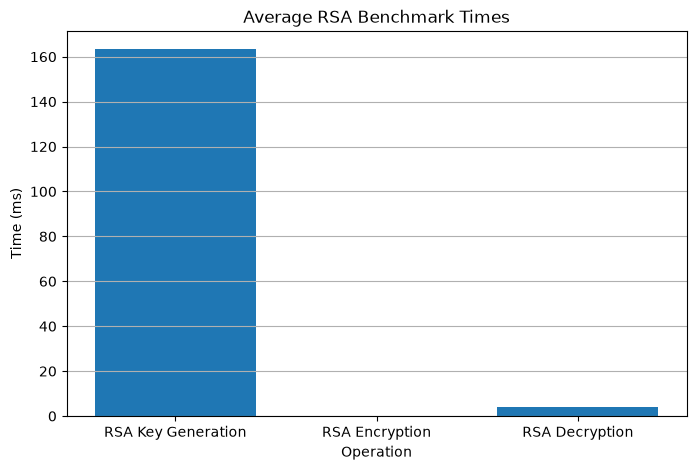

In [119]:
import os
import matplotlib.pyplot as plt

# Ensure folder exists
os.makedirs("results", exist_ok=True)

plt.figure(figsize=(8,5))

plt.bar(
    benchmark_results["Operation"],
    benchmark_results["Average Time (ms)"]
)

plt.title("Average RSA Benchmark Times")
plt.xlabel("Operation")
plt.ylabel("Time (ms)")
plt.grid(axis="y")

# ⭐ SAVE IMAGE (IMPORTANT LINE)
plt.savefig("results/rsa_benchmark_plot.png", dpi=300, bbox_inches="tight")

plt.show()

In [70]:

# Section 13: Post-Quantum Cryptography (ML-KEM)


In [73]:
import oqs

print("liboqs-python imported successfully!")

liboqs-python faulthandler is disabled
liboqs-python faulthandler is disabled
liboqs-python faulthandler is disabled
liboqs not found, installing it in /Users/triptigupta/_oqs
liboqs not found, installing it in /Users/triptigupta/_oqs
liboqs not found, installing it in /Users/triptigupta/_oqs
Installing in 5 seconds...
Installing in 5 seconds...
Installing in 5 seconds...
Installing in 4 seconds...
Installing in 4 seconds...
Installing in 4 seconds...
Installing in 3 seconds...
Installing in 3 seconds...
Installing in 3 seconds...
Installing in 2 seconds...
Installing in 2 seconds...
Installing in 2 seconds...
Installing in 1 seconds...
Installing in 1 seconds...
Installing in 1 seconds...


Cloning into 'liboqs'...
Note: switching to '97f6b86b1b6d109cfd43cf276ae39c2e776aed80'.

You are in 'detached HEAD' state. You can look around, make experimental
changes and commit them, and you can discard any commits you make in this
state without impacting any branches by switching back to a branch.

If you want to create a new branch to retain commits you create, you may
do so (now or later) by using -c with the switch command. Example:

  git switch -c <new-branch-name>

Or undo this operation with:

  git switch -

Turn off this advice by setting config variable advice.detachedHead to false

Updating files: 100% (7057/7057), done.


-- The C compiler identification is AppleClang 21.0.0.21000101
-- The ASM compiler identification is Clang with GNU-like command-line
-- Found assembler: /Applications/Xcode.app/Contents/Developer/Toolchains/XcodeDefault.xctoolchain/usr/bin/cc
-- Detecting C compiler ABI info
-- Detecting C compiler ABI info - done
-- Check for working C compiler: /Applications/Xcode.app/Contents/Developer/Toolchains/XcodeDefault.xctoolchain/usr/bin/cc - skipped
-- Detecting C compile features
-- Detecting C compile features - done
-- Performing Test CC_SUPPORTS_WA_NOEXECSTACK
-- Performing Test CC_SUPPORTS_WA_NOEXECSTACK - Success
-- Performing Test LD_SUPPORTS_WL_Z_NOEXECSTACK
-- Performing Test LD_SUPPORTS_WL_Z_NOEXECSTACK - Failed
-- Performing Test CMAKE_HAVE_LIBC_PTHREAD
-- Performing Test CMAKE_HAVE_LIBC_PTHREAD - Success
-- Found Threads: TRUE  
-- Alg enablement unchanged
-- Experimental stateful key and signature generation is enabled. Ensure secret keys are securely stored to prevent multipl

/var/folders/4j/x7jdx4vj2hb0dz88j77b5ph80000gn/T/tmpte6iz6md/liboqs/src/common/sha3/xkcp_low/KeccakP-1600/plain-64bits/KeccakP-1600-opt64.c:200:62: warning: implicit conversion loses integer precision: 'int' to 'unsigned char' [-Wimplicit-int-conversion]
  200 |                         ((unsigned char *)state)[lanePosition * 8 + offset + i] = ~data[i];
      |                                                                                 ~ ^~~~~~~~
/var/folders/4j/x7jdx4vj2hb0dz88j77b5ph80000gn/T/tmpte6iz6md/liboqs/src/common/sha3/xkcp_low/KeccakP-1600/plain-64bits/KeccakP-1600-opt64.c:384:3: warning: implicit conversion loses integer precision: 'int' to 'unsigned char' [-Wimplicit-int-conversion]
  384 |                 COMPL(1);
      |                 ^~~~~~~~
/var/folders/4j/x7jdx4vj2hb0dz88j77b5ph80000gn/T/tmpte6iz6md/liboqs/src/common/sha3/xkcp_low/KeccakP-1600/plain-64bits/KeccakP-1600-opt64.c:382:70: note: expanded from macro 'COMPL'
  382 | #define COMPL(lane) for(unsigned in

[  0%] Building C object src/common/CMakeFiles/common.dir/aes/aes.c.o
[  1%] Building C object src/kem/bike/CMakeFiles/kem_bike.dir/kem_bike.c.o
[  1%] Building C object src/sig_stfl/lms/CMakeFiles/lms.dir/external/hss_alloc.c.o
[  1%] Building C object src/common/CMakeFiles/common.dir/sha2/sha2_ossl.c.o
[  1%] Built target kem_bike
[  1%] Building C object src/kem/bike/CMakeFiles/bike_l1.dir/additional_r4/decode.c.o
[  1%] Building C object src/sig_stfl/lms/CMakeFiles/lms.dir/external/hss_aux.c.o
[  2%] Building C object src/common/CMakeFiles/common.dir/sha2/sha2.c.o
[  2%] Building C object src/common/CMakeFiles/common.dir/sha3/xkcp_sha3.c.o
[  2%] Building C object src/kem/bike/CMakeFiles/bike_l1.dir/additional_r4/decode_portable.c.o
[  2%] Building C object src/common/CMakeFiles/common.dir/sha3/xkcp_sha3x4.c.o
[  2%] Building C object src/sig_stfl/lms/CMakeFiles/lms.dir/external/hss_common.c.o
[  2%] Building C object src/kem/bike/CMakeFiles/bike_l1.dir/additional_r4/error.c.o
[  2

13 warnings generated.


[  6%] Building C object src/kem/ntru/CMakeFiles/ntru_hps2048509_clean.dir/pqclean_ntruhps2048509_clean/poly_r2_inv.c.o
[  6%] Building C object src/kem/ntru/CMakeFiles/ntru_hps2048677_clean.dir/kem_ntru_hps2048677.c.o
[  6%] Building C object src/kem/ntruprime/CMakeFiles/ntruprime_sntrup761_clean.dir/pqclean_sntrup761_clean/crypto_decode_761xint16.c.o
[  6%] Building C object src/kem/ntru/CMakeFiles/ntru_hps2048509_clean.dir/pqclean_ntruhps2048509_clean/poly_rq_mul.c.o
[  6%] Building C object src/kem/ntruprime/CMakeFiles/ntruprime_sntrup761_clean.dir/pqclean_sntrup761_clean/crypto_decode_761xint32.c.o
[  6%] Building C object src/kem/ntru/CMakeFiles/ntru_hps2048677_clean.dir/pqclean_ntruhps2048677_clean/cmov.c.o
[  7%] Building C object src/kem/ntruprime/CMakeFiles/ntruprime_sntrup761_clean.dir/pqclean_sntrup761_clean/crypto_encode_761x1531.c.o
[  7%] Building C object src/kem/ntru/CMakeFiles/ntru_hps2048677_clean.dir/pqclean_ntruhps2048677_clean/crypto_sort_int32.c.o
[  7%] Building

In [74]:
import oqs

kems = oqs.get_enabled_kem_mechanisms()

print(f"Total KEM algorithms available: {len(kems)}")
print("\nAvailable ML-KEM algorithms:")

for kem in kems:
    if "ML-KEM" in kem:
        print("-", kem)

Total KEM algorithms available: 32

Available ML-KEM algorithms:
- ML-KEM-512
- ML-KEM-768
- ML-KEM-1024


In [75]:
import oqs

print("liboqs Version:", oqs.oqs_version())

print("\nEnabled KEM Algorithms:")

kems = oqs.get_enabled_kem_mechanisms()

for kem in kems:
    print(kem)

liboqs Version: 0.15.0

Enabled KEM Algorithms:
BIKE-L1
BIKE-L3
BIKE-L5
Classic-McEliece-348864
Classic-McEliece-348864f
Classic-McEliece-460896
Classic-McEliece-460896f
Classic-McEliece-6688128
Classic-McEliece-6688128f
Classic-McEliece-6960119
Classic-McEliece-6960119f
Classic-McEliece-8192128
Classic-McEliece-8192128f
Kyber512
Kyber768
Kyber1024
ML-KEM-512
ML-KEM-768
ML-KEM-1024
NTRU-HPS-2048-509
NTRU-HPS-2048-677
NTRU-HPS-4096-821
NTRU-HPS-4096-1229
NTRU-HRSS-701
NTRU-HRSS-1373
sntrup761
FrodoKEM-640-AES
FrodoKEM-640-SHAKE
FrodoKEM-976-AES
FrodoKEM-976-SHAKE
FrodoKEM-1344-AES
FrodoKEM-1344-SHAKE


In [76]:
# Section 13A: Post-Quantum Key Exchange using ML-KEM-768

## Objective

#In the classical workflow, RSA-2048 is used to securely exchange an AES-256 session key before 
#encrypting banking transactions.

#In this section, RSA is replaced with the NIST-standardized ML-KEM-768 algorithm while keeping 
#AES-256 unchanged. 
#This demonstrates a prototype migration toward quantum-resistant key establishment for financial
#communication systems.

In [79]:

import oqs

kem = oqs.KeyEncapsulation("ML-KEM-768")

print("Algorithm:", kem.details["name"])

Algorithm: ML-KEM-768


In [80]:
public_key = kem.generate_keypair()

secret_key = kem.export_secret_key()

print("Public Key Length :", len(public_key), "bytes")

print("Secret Key Length :", len(secret_key), "bytes")

Public Key Length : 1184 bytes
Secret Key Length : 2400 bytes


In [81]:
ciphertext, shared_secret_sender = kem.encap_secret(public_key)

print("Ciphertext Length:", len(ciphertext))

print("Shared Secret Length:", len(shared_secret_sender))

Ciphertext Length: 1088
Shared Secret Length: 32


In [84]:
import oqs

kem_receiver = oqs.KeyEncapsulation("ML-KEM-768")

public_key = kem_receiver.generate_keypair()
secret_key = kem_receiver.export_secret_key()

In [85]:
kem_sender = oqs.KeyEncapsulation("ML-KEM-768")

ciphertext, shared_secret_sender = kem_sender.encap_secret(public_key)

In [86]:
shared_secret_receiver = kem_receiver.decap_secret(ciphertext)

In [87]:
print(shared_secret_sender == shared_secret_receiver)

True


In [88]:
#HKDF + AES Integration

In [89]:
import oqs
import os
from cryptography.hazmat.primitives.kdf.hkdf import HKDF
from cryptography.hazmat.primitives import hashes

In [90]:
kem = oqs.KeyEncapsulation("ML-KEM-768")

public_key = kem.generate_keypair()
secret_key = kem.export_secret_key()

# assume ciphertext comes from sender
shared_secret = kem.decap_secret(ciphertext)

# HKDF → AES key (32 bytes = AES-256)
hkdf = HKDF(
    algorithm=hashes.SHA256(),
    length=32,
    salt=None,
    info=b"pqc-aes-key",
)

aes_key = hkdf.derive(shared_secret)

In [91]:
from cryptography.hazmat.primitives.ciphers.aead import AESGCM

aesgcm = AESGCM(aes_key)

nonce = os.urandom(12)
plaintext = b"Hello secure world"

ciphertext = aesgcm.encrypt(nonce, plaintext, None)

In [92]:
aesgcm = AESGCM(aes_key)

decrypted = aesgcm.decrypt(nonce, ciphertext, None)

print(decrypted)

b'Hello secure world'


In [96]:
ciphertext_kem, ss_sender = kem.encap_secret(public_key)

hkdf = HKDF(
    algorithm=hashes.SHA256(),
    length=32,
    salt=None,
    info=b"pqc-aes-key",
)

aes_key = hkdf.derive(ss_sender)

aesgcm = AESGCM(aes_key)
nonce = os.urandom(12)

ciphertext = aesgcm.encrypt(nonce, b"message", None)

In [98]:
def derive_aes_key(shared_secret):
    hkdf = HKDF(
        algorithm=hashes.SHA256(),
        length=32,
        salt=None,
        info=b"pqc-aes-key",
    )
    return hkdf.derive(shared_secret)

In [99]:
aes_key = derive_aes_key(ss_receiver)

In [101]:
#benchmarking 

In [107]:
#KEM
import time

runs = 100
start = time.time()

for _ in range(runs):
    kem.encap_secret(public_key)

end = time.time()

print("Avg KEM encaps time:", (end - start) / runs)

Avg KEM encaps time: 5.34820556640625e-05


In [108]:
#decapsulation
runs = 100

start = time.time()

for _ in range(runs):
    kem.decap_secret(ciphertext_kem)

end = time.time()

print("Avg Decap time:", (end - start) / runs)

Avg Decap time: 7.905960083007813e-05


In [112]:
# AES
from cryptography.hazmat.primitives.ciphers.aead import AESGCM
import os
import time

aesgcm = AESGCM(aes_key)
plaintext = b"test" * 1000

runs = 100

start = time.time()

for _ in range(runs):
    nonce = os.urandom(12)
    ciphertext = aesgcm.encrypt(nonce, plaintext, None)

end = time.time()

print("Avg AES-GCM encrypt time:", (end - start) / runs)

aes_runs = 100
start = time.time()

for _ in range(aes_runs):
    nonce = os.urandom(12)
    aesgcm.encrypt(nonce, plaintext, None)

end = time.time()

aes_enc_time = (end - start) / aes_runs
print("AES avg:", aes_enc_time)

Avg AES-GCM encrypt time: 2.1860599517822265e-05
AES avg: 1.5630722045898438e-05


In [113]:
import time

runs = 30

# Encapsulation
start = time.time()
for _ in range(runs):
    kem.encap_secret(public_key)
end = time.time()

kem_encap_avg = (end - start) / runs

# Decapsulation
start = time.time()
for _ in range(runs):
    kem.decap_secret(ciphertext_kem)
end = time.time()

kem_decap_avg = (end - start) / runs

print(kem_encap_avg, kem_decap_avg)

9.003480275472005e-05 5.8372815450032554e-05


In [114]:
results = {
    "ML-KEM Encapsulation": kem_encap_avg,
    "ML-KEM Decapsulation": kem_decap_avg,
    "AES-GCM Encryption": aes_enc_time  # (we will define next)
}

print(results)

{'ML-KEM Encapsulation': 9.003480275472005e-05, 'ML-KEM Decapsulation': 5.8372815450032554e-05, 'AES-GCM Encryption': 1.5630722045898438e-05}


In [117]:
import os
os.makedirs("results", exist_ok=True)

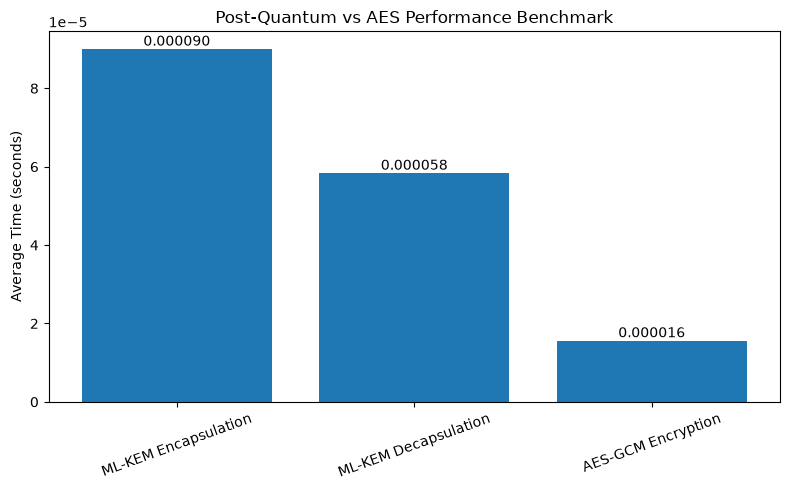

In [118]:
import os
import matplotlib.pyplot as plt

# Create folder if it doesn't exist
os.makedirs("results", exist_ok=True)

# Data from your benchmarks
operations = [
    "ML-KEM Encapsulation",
    "ML-KEM Decapsulation",
    "AES-GCM Encryption"
]

times = [
    kem_encap_avg,
    kem_decap_avg,
    aes_enc_time
]

# Create plot
plt.figure(figsize=(8,5))
plt.bar(operations, times)

plt.title("Post-Quantum vs AES Performance Benchmark")
plt.ylabel("Average Time (seconds)")
plt.xticks(rotation=20)

for i, v in enumerate(times):
    plt.text(i, v, f"{v:.6f}", ha='center', va='bottom')

plt.tight_layout()

# Save PNG
plt.savefig("results/pqc_vs_aes_plot.png", dpi=300, bbox_inches="tight")

plt.show()